In [1]:
from synthetic_workloads import *
import matplotlib.pyplot as plt

/home/dylan/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
results_path = './activations/'
filename_qwen = results_path + 'activations_qwen_samples15000_20260814083534.pkl'
filename_example = results_path + 'activations_mistral_example.pkl'

In [3]:
results = get_results(filename_qwen)

In [4]:
n_experts = results[0]['probs'].shape[1]
n_layers = results[0]['probs'].shape[2]
n_samples = len(results)
k = results[0]['active_experts'].shape[1]
n_requested_prompts = 100

generating synthetic workload for target CV: 0.10000000149011612...
generating synthetic workload for target CV: 0.15000000596046448...
generating synthetic workload for target CV: 0.20000000298023224...
generating synthetic workload for target CV: 0.25...
generating synthetic workload for target CV: 0.30000001192092896...
generating synthetic workload for target CV: 0.3499999940395355...
generating synthetic workload for target CV: 0.4000000059604645...
generating synthetic workload for target CV: 0.44999998807907104...
generating synthetic workload for target CV: 0.5...
generating synthetic workload for target CV: 0.550000011920929...
generating synthetic workload for target CV: 0.6000000238418579...
generating synthetic workload for target CV: 0.6499999761581421...
generating synthetic workload for target CV: 0.699999988079071...
generating synthetic workload for target CV: 0.75...
generating synthetic workload for target CV: 0.800000011920929...
generating synthetic workload for ta

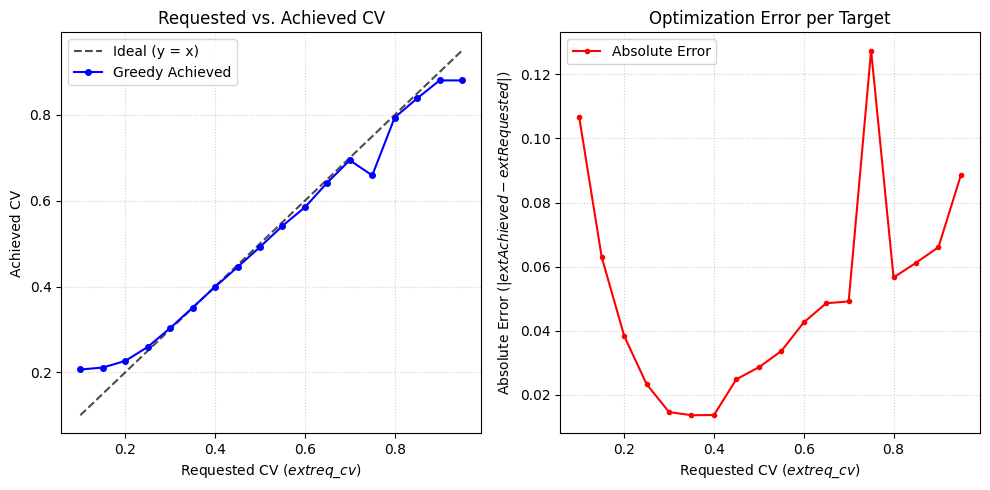

In [5]:
# Now search for workloads which fit a range of CVs
target_cvs = torch.arange(0.1, 1.0, 0.05)
obtained_cvs = []
maes = []
for req_cv in target_cvs:
    print(f'generating synthetic workload for target CV: {req_cv}...')
    req_cvs = torch.ones((n_layers)) * req_cv
    _, cvs = construct_workload_cvs(results, n_requested_prompts, req_cvs, allow_repeats=True)
    metrics = evaluate_workload_quality_cvs(req_cvs, cvs)
    obtained_cvs.append(torch.mean(cvs))
    maes.append(metrics['mae'])

# Plot the Results
plt.figure(figsize=(10, 5))

# Subplot 1: Requested vs Achieved average CV
plt.subplot(1, 2, 1)
plt.plot(target_cvs, target_cvs, 'k--', label="Ideal (y = x)", alpha=0.7)
plt.plot(target_cvs, obtained_cvs, 'bo-', label="Greedy Achieved", markersize=4)
plt.xlabel("Requested CV ($\text{req\_cv}$)")
plt.ylabel("Achieved CV")
plt.title("Requested vs. Achieved CV")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()

# Subplot 2: Absolute Error per Target
plt.subplot(1, 2, 2)
plt.plot(target_cvs, maes, 'r.-', label="Absolute Error")
plt.xlabel("Requested CV ($\text{req\_cv}$)")
plt.ylabel("Absolute Error ($|\text{Achieved} - \text{Requested}|$)")
plt.title("Optimization Error per Target")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()